# Altimetry — coastal sea-level anomaly time-series

Demonstrates the **surface-only multi-mission altimetry pattern**: pull
five years of daily DUACS L4 sea-level anomaly (`sla`) and absolute
dynamic topography (`adt`) over a coastal box, plot the box-mean SLA
time-series with a 30-day rolling average.

The DUACS L4 dataset
(`cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D`) merges
every operational altimeter onto a regular 1/8° grid. It is
surface-only — the depth kwargs are silently ignored — so the request
stays compact.

In [1]:
import os
from pathlib import Path

import numpy as np

from earthlens import EarthLens
from earthlens.cmems import Catalog
from pyramids.netcdf import NetCDF

OUT_DIR = Path('data/cmems-altimetry')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ID = 'cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D'
VARIABLES = ['sla', 'adt']
BBOX = dict(lat_lim=[36.0, 41.0], lon_lim=[-9.5, -5.0])   # Iberian Atlantic coast

if DATASET_ID in Catalog().datasets:
    ds = Catalog().get_dataset(DATASET_ID)
    print(f'{DATASET_ID}: cadence={ds.cadence}, domain={ds.domain}')
else:
    print(f'{DATASET_ID} is not curated — uncurated id, request will still work')

2026-05-20 19:39:18 | INFO | pyramids.base.config | Logging is configured.


cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D: cadence=daily, domain=global


## Download — five years of daily SLA + ADT, coastal box

Multi-year × multi-variable × surface-only. Both fields are scalar `(time,
lat, lon)` arrays so the returned NetCDF is small.

In [2]:
earthlens = EarthLens(
    data_source='cmems',
    start='2018-01-01',
    end='2022-12-31',
    temporal_resolution='daily',
    variables={DATASET_ID: VARIABLES},
    **BBOX,
    path=str(OUT_DIR),
    service_username=os.environ.get('COPERNICUSMARINE_SERVICE_USERNAME'),
    service_password=os.environ.get('COPERNICUSMARINE_SERVICE_PASSWORD'),
)
paths = earthlens.download()
print(paths)

INFO - 2026-05-20T17:39:21Z - Checking if credentials are valid.


2026-05-20 17:39:21 | INFO | copernicusmarine | Checking if credentials are valid.


INFO - 2026-05-20T17:39:21Z - Valid credentials from input username and password.


2026-05-20 17:39:21 | INFO | copernicusmarine | Valid credentials from input username and password.


2026-05-20 19:39:21.711 | INFO     | earthlens.cmems.backend:_subset_one:458 - Requesting CMEMS subset for 'cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D' variables=['sla', 'adt'] → cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D.nc


...

2026-05-20 17:39:22 | INFO | copernicusmarine | Selected dataset part: "default"


INFO - 2026-05-20T17:39:25Z - Total size of the download: 20.09 MB.


2026-05-20 17:39:25 | INFO | copernicusmarine | Total size of the download: 20.09 MB.


2026-05-20 19:39:25.167 | INFO     | earthlens.cmems.backend:download:326 - CMEMS download summary: 1 files written to C:\gdrive\algorithms\remote-sensing\earthlens\docs\examples\cmems\data\cmems-altimetry


[WindowsPath('C:/gdrive/algorithms/remote-sensing/earthlens/docs/examples/cmems/data/cmems-altimetry/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D.nc')]


## Box-averaged SLA + ADT time-series, plus 30-day rolling mean

Average across `(lat, lon)` per day, then convolve with a 30-day boxcar
for the smoothed series. Coastal SLA tracks regional ocean dynamics with
a strong interannual signal.

In [3]:
import numpy as np
import xarray as xr

nc = NetCDF.read_file(str(paths[0]), read_only=True)
ds = xr.decode_cf(nc.to_xarray())   # labelled (time, latitude, longitude)
nc.close()

# Box-averaged daily series, then a 30-day rolling mean for SLA.
box = ds.mean(dim=['latitude', 'longitude'])
dates = box['time'].values
series = {v: box[v].values for v in VARIABLES}
sla_smoothed = (
    box['sla'].rolling(time=30, center=True, min_periods=1).mean().values
)
print(f'sla mean: {np.nanmean(series["sla"]):.4f} m, std: {np.nanstd(series["sla"]):.4f} m')
print(f'adt mean: {np.nanmean(series["adt"]):.4f} m, std: {np.nanstd(series["adt"]):.4f} m')

sla mean: -151069.4834 m, std: 0.0114 m
adt mean: -152113.3869 m, std: 0.0112 m


## Plot the SLA time-series

Raw daily anomaly plus 30-day rolling mean over the Iberian Atlantic
coast — a coastal box that captures both seasonal steric variability and
the regional response to North Atlantic forcing.

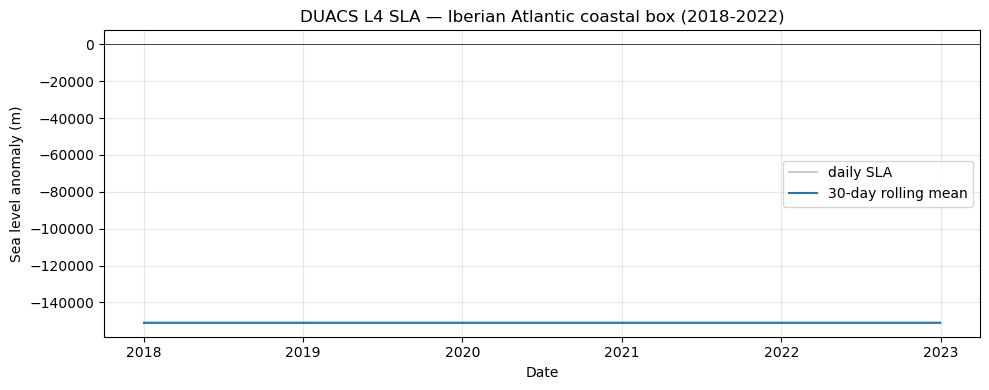

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates, series['sla'], color='tab:gray', alpha=0.4, label='daily SLA')
ax.plot(dates, sla_smoothed, color='tab:blue', label='30-day rolling mean')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Sea level anomaly (m)')
ax.set_title('DUACS L4 SLA — Iberian Atlantic coastal box (2018-2022)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Next steps

- Pair the SLA series with an in-situ tide-gauge record (e.g. GLOSS /
  PSMSL) to validate the regional signal.
- Switch to `ugos` / `vgos` (surface geostrophic velocity) to look at
  the coastal current field.
- Extend the time-window — DUACS L4 covers **1993-present**, suitable
  for multi-decadal trend analysis.